# Comparisons with BGEP ULS sea ice draft estimates updated with new data

**Summary:** In this notebook, we produce comparisons of the gridded ICESat-2 sea ice thickness data with draft measurements obtained from Upward Looking Sonar moorings deployed in the Beaufort Sea. 

 
**Version history**: Version 1 (01/01/2022)
 

# Import notebook dependencies

In [2]:
import xarray as xr 
import pandas as pd
import numpy as np
import itertools
import pyproj 
from netCDF4 import Dataset
import scipy.interpolate 
from utils.read_data_utils import read_book_data, read_IS2SITMOGR4 # Helper function for reading the data from the bucket
from utils.plotting_utils import compute_gridcell_winter_means, interactiveArcticMaps, interactive_winter_mean_maps, interactive_winter_comparison_lineplot # Plotting
from scipy import stats
import datetime
# Plotting dependencies
import cartopy.crs as ccrs
from textwrap import wrap
import hvplot.pandas
import holoviews as hv
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from cartopy.mpl.geoaxes import GeoAxes
GeoAxes._pcolormesh_patched = Axes.pcolormesh # Helps avoid some weird issues with the polar projection 
%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 200 # Sets figure size in the notebook

# Remove warnings to improve display
import warnings 
warnings.filterwarnings('ignore') 


In [3]:
# DO ONE RUN APR 2021 WITH SM AS THIS IS WHEN IT IS AVAILABLE TO
  
start_date = "Nov 2018"
end_date = "Apr 2021"
options = {
    'nsim': {'thickness': 'ice_thickness', 'snow_depth': 'snow_depth'},
    'sm': {'thickness': 'ice_thickness_sm', 'snow_depth': 'snow_depth_sm'},
    'mw99': {'thickness': 'ice_thickness_mw99', 'snow_depth': 'snow_depth_mw99'},
    'j22': {'thickness': 'ice_thickness_j22', 'snow_depth': 'snow_depth'}
}

# DO A FULL RUN UP TO 2023

#start_date = "Nov 2018"
#end_date = "Apr 2023"
#options = {
#    'nsim': {'thickness': 'ice_thickness', 'snow_depth': 'snow_depth'},
#    'nsim_int': {'thickness': 'ice_thickness_int', 'snow_depth': 'snow_depth_int'},
#    'mw99': {'thickness': 'ice_thickness_mw99', 'snow_depth': 'snow_depth_mw99'},
#    'j22': {'thickness': 'ice_thickness_j22', 'snow_depth': 'snow_depth'}}




In [4]:
IS2SITMOGR4_v3 = read_IS2SITMOGR4(data_type='zarr-s3', persist=True) 

IS2SITMOGR4_v3

load zarr from S3 bucket
zarr_path: s3://icesat-2-sea-ice-us-west-2/IS2SITMOGR4_V3/IS2SITMOGR4_V3_201811-202404.zarr
<xarray.Dataset>
Dimensions:                         (time: 46, y: 448, x: 304)
Coordinates:
    latitude                        (y, x) float32 dask.array<chunksize=(224, 304), meta=np.ndarray>
    longitude                       (y, x) float32 dask.array<chunksize=(224, 304), meta=np.ndarray>
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/27)
    crs                             (time) int32 dask.array<chunksize=(46,), meta=np.ndarray>
    freeboard                       (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard_int                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density        

<xarray.Dataset>
Dimensions:                         (time: 46, y: 448, x: 304)
Coordinates:
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/27)
    crs                             (time) int32 dask.array<chunksize=(46,), meta=np.ndarray>
    freeboard                       (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard_int                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density                     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density_j22                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_density_sm                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 V3 dataset.
    history:      Created 28/11/23
    reference:    Official NSIDC data doi: 10.5067/CV6JEXEE31HF. Derived data...

In [5]:
book_ds = read_book_data(CS2=True)
#book_ds = book_ds.rename({'x': 'xgrid', 'y': 'ygrid'})
# Remove the x and y coordinates from the IS2SITMOGR4_v3 dataset

# Add 1D x and y coordinates
book_ds = book_ds.assign_coords(
    x=book_ds['xgrid'][0, :],  # Assuming xgrid is 2D, take the first row
    y=book_ds['ygrid'][:, 0]   # Assuming ygrid is 2D, take the first column
)
book_ds = book_ds.drop_vars(['xgrid', 'ygrid'])

book_ds

<xarray.Dataset>
Dimensions:                        (time: 30, y: 448, x: 304)
Coordinates:
  * time                           (time) datetime64[ns] 2018-11-01 ... 2021-...
    longitude                      (y, x) float32 ...
    latitude                       (y, x) float32 ...
  * x                              (x) float32 -3.838e+06 ... 3.738e+06
  * y                              (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/25)
    projection                     (time) float64 ...
    ice_thickness                  (time, y, x) float32 ...
    ice_thickness_unc              (time, y, x) float32 ...
    num_segments                   (time, y, x) float32 ...
    mean_day_of_month              (time, y, x) float32 ...
    snow_depth                     (time, y, x) float32 ...
    ...                             ...
    y_vel                          (time, y, x) float64 ...
    cs2_sea_ice_thickness_GSFC     (time, y, x) float32 ...
    cs2_sea_ice_thickness_CPOM     (time, y, x) float32 ...
    cs2_sea_ice_thickness_AWISMOS  (time, y, x) float64 ...
    cs2_sea_ice_thickness_UBRIS    (time, y, x) float64 ...
    cs2_sea_ice_thickness_KK       (time, y, x) float64 ...
Attributes:
    contact:      Alek Petty (alek.a.petty@nasa.gov)
    description:  Gridded Oct 2019 Arctic sea ice thickness and ancillary dat...
    reference:    Data doi: 10.5067/CV6JEXEE31HF. Original methodology descri...
    history:      Created 21/01/22

In [6]:
IS2SITMOGR4_v3 = IS2SITMOGR4_v3.assign(cs2_sea_ice_thickness_UBRIS=book_ds['cs2_sea_ice_thickness_UBRIS'])
IS2SITMOGR4_v3

<xarray.Dataset>
Dimensions:                         (time: 46, x: 304, y: 448)
Coordinates:
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
Data variables: (12/28)
    crs                             (time) int32 dask.array<chunksize=(46,), meta=np.ndarray>
    freeboard                       (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard_int                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density                     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density_j22                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    cs2_sea_ice_thickness_UBRIS     (time, y, x) float64 0.0 0.0 0.0 ... nan nan
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 V3 dataset.
    history:      Created 28/11/23
    reference:    Official NSIDC data doi: 10.5067/CV6JEXEE31HF. Derived data...

In [7]:
# Issue in how region mask was assigned
IS2SITMOGR4_v3['region_mask'] = IS2SITMOGR4_v3['region_mask'].isel(time=0, drop=True)


In [8]:
# Define the cutoff date
#cutoff_date = pd.Timestamp('2021-08-15')

# Filter the data to include only dates up to the cutoff date to be consistent with SM
#IS2SITMOGR4_v3 = IS2SITMOGR4_v3.where(IS2SITMOGR4_v3['time'] >= cutoff_date, drop=True)



In [9]:
# Estimate ice draft from the ICESat-2 data for more direct comparison with ULS draft measurements
# NB: Another option (not taken) is to simply multiply ULS drafts by 1.1 to convert to thickness (AWI do this)
# Include extra var = '_int' to use interpolated values, not recommended for validation purposes. 
# Define the variables for each option


# Calculate ice draft for each option
for option, vars in options.items():
    thickness_var = vars['thickness']
    snow_depth_var = vars['snow_depth']
    IS2SITMOGR4_v3[f'ice_draft_{option}'] = (IS2SITMOGR4_v3[thickness_var] - IS2SITMOGR4_v3['freeboard'] + IS2SITMOGR4_v3[snow_depth_var])

In [10]:
options.keys()

dict_keys(['nsim', 'sm', 'mw99', 'j22'])

In [11]:
# Initialize map projection and project data to it

out_proj = 'EPSG:3411'
out_lons = IS2SITMOGR4_v3.longitude.values
out_lats = IS2SITMOGR4_v3.latitude.values

mapProj = pyproj.Proj("+init=" + out_proj)
xptsIS2, yptsIS2 = mapProj(out_lons, out_lats)


IS2_date_range = pd.date_range(start=start_date, end=end_date, freq='MS') # MS indicates a time frequency of start of the month
IS2_date_range = IS2_date_range[((IS2_date_range.month <5) | (IS2_date_range.month > 8))]
IS2_date_range_strs=[str(date.year)+'-%02d'%(date.month) for date in IS2_date_range]


In [12]:
# This is the value in meters of the aggregation length-scale for the ICESat-2 data
comp_res=50000

In [13]:
# Wrange ULS data
# Could really convert this to another data wrangling notebook and store the derived output as netcdfs

dataPathULS='./data/'

def get_ULS_dates(uls_mean_monthly_draft, uls_dates, date):
    #print(date)
    a = uls_mean_monthly_draft[uls_dates==date].values[0]
    return a

def get_uls_year(letter, year):
    if letter=='a':
        print('Mooring A (75.0 N, 150 W)')
        uls_x, uls_y = mapProj(-150., 75.)
    if letter=='b':
        print('Mooring B (78.4 N, 150.0 W)')
        uls_x, uls_y = mapProj(-150., 78.4)
    if letter=='d':
        print('Mooring D (74.0 N, 140.0 W)')
        uls_x, uls_y = mapProj(-140., 74.)
 
    uls = pd.read_csv(dataPathULS+'uls'+year+letter+'_draft.dat', sep='\s+',names = ['date', 'time', 'draft'], header=2)
    utc_datetime_uls = pd.to_datetime(uls['date'], format='%Y%m%d')
    uls_mean_daily_draft = uls['draft'].groupby([utc_datetime_uls.dt.date]).mean() 

    uls_mean_monthly_draft = uls['draft'].groupby([utc_datetime_uls.dt.to_period('m')]).mean() 
    #print(uls_mean_monthly_draft)
    
    return uls_mean_daily_draft, uls_mean_monthly_draft, uls_x, uls_y




In [14]:
uls_mean_daily_draft_a_18, uls_mean_monthly_draft_a_18, uls_x_a, uls_y_a = get_uls_year('a', '18')
uls_mean_daily_draft_b_18, uls_mean_monthly_draft_b_18, uls_x_b, uls_y_b = get_uls_year('b', '18')
uls_mean_daily_draft_d_18, uls_mean_monthly_draft_d_18, uls_x_d, uls_y_d = get_uls_year('d', '18')

Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)


In [15]:
uls_mean_daily_draft_a_21, uls_mean_monthly_draft_a_21, _, _ = get_uls_year('a', '21')
uls_mean_daily_draft_b_21, uls_mean_monthly_draft_b_21, _, _ = get_uls_year('b', '21')
uls_mean_daily_draft_d_21, uls_mean_monthly_draft_d_21, _, _ = get_uls_year('d', '21')   

Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)


In [16]:
uls_mean_daily_draft_a_22, uls_mean_monthly_draft_a_22, _, _ = get_uls_year('a', '22')
uls_mean_daily_draft_b_22, uls_mean_monthly_draft_b_22, _, _ = get_uls_year('b', '22')
uls_mean_daily_draft_d_22, uls_mean_monthly_draft_d_22, _, _ = get_uls_year('d', '22')   

Mooring A (75.0 N, 150 W)
Mooring B (78.4 N, 150.0 W)
Mooring D (74.0 N, 140.0 W)


In [17]:
# Combine data for all years
uls_mean_daily_draft_a = pd.concat([uls_mean_daily_draft_a_18, uls_mean_daily_draft_a_21, uls_mean_daily_draft_a_22])
uls_mean_daily_draft_b = pd.concat([uls_mean_daily_draft_b_18, uls_mean_daily_draft_b_21, uls_mean_daily_draft_b_22])
uls_mean_daily_draft_d = pd.concat([uls_mean_daily_draft_d_18, uls_mean_daily_draft_d_21, uls_mean_daily_draft_d_22])

# Combine data for all years
uls_mean_monthly_draft_a = pd.concat([uls_mean_monthly_draft_a_18, uls_mean_monthly_draft_a_21, uls_mean_monthly_draft_a_22])
uls_mean_monthly_draft_b = pd.concat([uls_mean_monthly_draft_b_18, uls_mean_monthly_draft_b_21, uls_mean_monthly_draft_b_22])
uls_mean_monthly_draft_d = pd.concat([uls_mean_monthly_draft_d_18, uls_mean_monthly_draft_d_21, uls_mean_monthly_draft_d_22])

In [18]:
def grid_IS2_nearby(date, option, uls_x, uls_y, res=50000):
    #print(date)
    IS2 = IS2SITMOGR4_v3['ice_draft_'+option].sel(time=date)
    xptsIS2g, yptsIS2g = mapProj(IS2.longitude.values, IS2.latitude.values)
    
    dist = np.sqrt( (xptsIS2 - uls_x)**2 + (yptsIS2 - uls_y)**2 )
    
    IS2_uls = IS2.where(dist<res).mean()
    
    #print('Number of valid IS-2 grid cells in month '+str(date)[0:7]+':', np.count_nonzero(~np.isnan(IS2.where(dist<res))))
    
    #Another option I first explored, coarsen the data then do nearest neighbor...provided similar results but above is more flexible.
    #if coarse_res>1:
    #Coarsen array by coarse_res in x/y directions (note that each grid-cell represents 25 km so 4 = 100 km)
    #    IS2 = IS2.coarsen(x=res, y=res, boundary='pad').mean()
    #IS2_uls = scipy.interpolate.griddata((xptsIS2g.flatten(), yptsIS2g.flatten()), IS2.values.flatten(), (uls_x, uls_y), method = 'nearest')
    
    return IS2_uls


# Compute monthly ULS values for each option
monthly_IS2_at_ULS_a_options = {}
monthly_IS2_at_ULS_b_options = {}
monthly_IS2_at_ULS_d_options = {}
monthly_IS2_at_ULS_all_options = {}

for option in options.keys():
    monthly_IS2_at_ULS_a_options[option] = [
        grid_IS2_nearby(date, option, uls_x_a, uls_y_a, res=comp_res) for date in IS2_date_range
    ]
    monthly_IS2_at_ULS_b_options[option] = [
        grid_IS2_nearby(date, option,uls_x_b, uls_y_b, res=comp_res) for date in IS2_date_range
    ]
    monthly_IS2_at_ULS_d_options[option] = [
        grid_IS2_nearby(date, option,uls_x_d, uls_y_d, res=comp_res) for date in IS2_date_range
    ]
    # Combine all ULS values for the current option
    monthly_IS2_at_ULS_all_options[option] = (
        monthly_IS2_at_ULS_a_options[option] +
        monthly_IS2_at_ULS_b_options[option] +
        monthly_IS2_at_ULS_d_options[option]
    )


In [19]:
monthly_IS2_at_ULS_all_options[option]

[<xarray.DataArray 'ice_draft_j22' ()>
 dask.array<mean_agg-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
 Coordinates:
     time     datetime64[ns] 2018-11-01,
 <xarray.DataArray 'ice_draft_j22' ()>
 dask.array<mean_agg-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
 Coordinates:
     time     datetime64[ns] 2018-12-01,
 <xarray.DataArray 'ice_draft_j22' ()>
 dask.array<mean_agg-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
 Coordinates:
     time     datetime64[ns] 2019-01-01,
 <xarray.DataArray 'ice_draft_j22' ()>
 dask.array<mean_agg-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
 Coordinates:
     time     datetime64[ns] 2019-02-01,
 <xarray.DataArray 'ice_draft_j22' ()>
 dask.array<mean_agg-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
 Coordinates:
     time     datetime64[ns] 2019-03-01,
 <xarray.DataArray 'ice_draft_j22' ()>
 dask.array

In [20]:
uls_dates=uls_mean_monthly_draft_a.index.astype(str)
uls_mean_monthly_draft_a_IS2_period  = [get_ULS_dates(uls_mean_monthly_draft_a, uls_dates, date) for date in IS2_date_range_strs]

uls_dates=uls_mean_monthly_draft_b.index.astype(str)
uls_mean_monthly_draft_b_IS2_period  = [get_ULS_dates(uls_mean_monthly_draft_b, uls_dates, date) for date in IS2_date_range_strs]

uls_dates=uls_mean_monthly_draft_d.index.astype(str)
uls_mean_monthly_draft_d_IS2_period  = [get_ULS_dates(uls_mean_monthly_draft_d, uls_dates, date) for date in IS2_date_range_strs]
                                        
uls_mean_monthly_draft_IS2_period = uls_mean_monthly_draft_a_IS2_period+uls_mean_monthly_draft_b_IS2_period+uls_mean_monthly_draft_d_IS2_period


In [21]:
# Validation analysis for each option
validation_results = {}

for option in options.keys():
    # ULS A
    mask_a = ~np.isnan(monthly_IS2_at_ULS_a_options[option])
    res_a = stats.linregress(
        np.array(monthly_IS2_at_ULS_a_options[option])[mask_a],
        np.array(uls_mean_monthly_draft_a_IS2_period)[mask_a]
    )
    r_str_a = '%.02f' % (res_a[2]**2)
    mb_str_a = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_a_options[option]) - np.array(uls_mean_monthly_draft_a_IS2_period)))
    sd_str_a = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_a_options[option]) - np.array(uls_mean_monthly_draft_a_IS2_period)))

    # ULS B
    mask_b = ~np.isnan(monthly_IS2_at_ULS_b_options[option])
    res_b = stats.linregress(
        np.array(monthly_IS2_at_ULS_b_options[option])[mask_b],
        np.array(uls_mean_monthly_draft_b_IS2_period)[mask_b]
    )
    r_str_b = '%.02f' % (res_b[2]**2)
    mb_str_b = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_b_options[option]) - np.array(uls_mean_monthly_draft_b_IS2_period)))
    sd_str_b = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_b_options[option]) - np.array(uls_mean_monthly_draft_b_IS2_period)))

    # ULS D
    mask_d = ~np.isnan(monthly_IS2_at_ULS_d_options[option])
    res_d = stats.linregress(
        np.array(monthly_IS2_at_ULS_d_options[option])[mask_d],
        np.array(uls_mean_monthly_draft_d_IS2_period)[mask_d]
    )
    r_str_d = '%.02f' % (res_d[2]**2)
    mb_str_d = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_d_options[option]) - np.array(uls_mean_monthly_draft_d_IS2_period)))
    sd_str_d = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_d_options[option]) - np.array(uls_mean_monthly_draft_d_IS2_period)))

    # ULS ALL
    mask_all = ~np.isnan(monthly_IS2_at_ULS_all_options[option])
    res_all = stats.linregress(
        np.array(monthly_IS2_at_ULS_all_options[option])[mask_all],
        np.array(uls_mean_monthly_draft_IS2_period)[mask_all]
    )
    r_str_all = '%.02f' % (res_all[2]**2)
    mb_str_all = '%.02f' % (np.nanmean(np.array(monthly_IS2_at_ULS_all_options[option]) - np.array(uls_mean_monthly_draft_IS2_period)))
    sd_str_all = '%.02f' % (np.nanstd(np.array(monthly_IS2_at_ULS_all_options[option]) - np.array(uls_mean_monthly_draft_IS2_period)))

    # Store results
    validation_results[option] = {
        'r_str_a': r_str_a, 'mb_str_a': mb_str_a, 'sd_str_a': sd_str_a,
        'r_str_b': r_str_b, 'mb_str_b': mb_str_b, 'sd_str_b': sd_str_b,
        'r_str_d': r_str_d, 'mb_str_d': mb_str_d, 'sd_str_d': sd_str_d,
        'r_str_all': r_str_all, 'mb_str_all': mb_str_all, 'sd_str_all': sd_str_all
    }

validation_results

{'nsim': {'r_str_a': '0.93',
  'mb_str_a': '0.13',
  'sd_str_a': '0.13',
  'r_str_b': '0.87',
  'mb_str_b': '0.01',
  'sd_str_b': '0.22',
  'r_str_d': '0.90',
  'mb_str_d': '0.20',
  'sd_str_d': '0.19',
  'r_str_all': '0.86',
  'mb_str_all': '0.11',
  'sd_str_all': '0.20'},
 'sm': {'r_str_a': '0.84',
  'mb_str_a': '0.11',
  'sd_str_a': '0.20',
  'r_str_b': '0.76',
  'mb_str_b': '0.05',
  'sd_str_b': '0.31',
  'r_str_d': '0.84',
  'mb_str_d': '0.22',
  'sd_str_d': '0.21',
  'r_str_all': '0.76',
  'mb_str_all': '0.12',
  'sd_str_all': '0.26'},
 'mw99': {'r_str_a': '0.92',
  'mb_str_a': '0.00',
  'sd_str_a': '0.17',
  'r_str_b': '0.92',
  'mb_str_b': '0.05',
  'sd_str_b': '0.17',
  'r_str_d': '0.75',
  'mb_str_d': '-0.04',
  'sd_str_d': '0.27',
  'r_str_all': '0.85',
  'mb_str_all': '0.00',
  'sd_str_all': '0.21'},
 'j22': {'r_str_a': '0.95',
  'mb_str_a': '0.26',
  'sd_str_a': '0.12',
  'r_str_b': '0.89',
  'mb_str_b': '0.17',
  'sd_str_b': '0.21',
  'r_str_d': '0.90',
  'mb_str_d': '0.2

In [22]:
import panel as pn
pn.extension()

# Define a function to create plots for a given option
def create_comb_plot(option):
    # Daily
    uls_a_daily_lineplot_p = uls_mean_daily_draft_a.hvplot.line(grid=True, label="daily ULS", line_dash='solid', color='gray', frame_width=700, frame_height=200).opts(title='ULS A', xaxis=None, ylabel="Ice draft (meters)")
    uls_b_daily_lineplot_p = uls_mean_daily_draft_b.hvplot.line(grid=True, line_dash='solid', color='gray', frame_width=700, frame_height=200).opts(title='ULS B', xaxis=None, ylabel="Ice draft (meters)")
    uls_d_daily_lineplot_p = uls_mean_daily_draft_d.hvplot.line(grid=True, line_dash='solid', color='gray', frame_width=700, frame_height=200).opts(title='ULS D', ylabel="Ice draft (meters)")

    # Monthly
    ULS_date_range_a = uls_mean_monthly_draft_a.index.to_timestamp() + pd.Timedelta(days=14)
    uls_mean_monthly_draft_a_reindex = pd.Series(data=uls_mean_monthly_draft_a.values, index=ULS_date_range_a) 
    uls_a_monthly_lineplot_p = uls_mean_monthly_draft_a_reindex.hvplot.line(grid=True, label="monthly ULS", line_dash='dashed', color='k', frame_width=700, frame_height=200).opts(ylabel="Ice draft (meters)")

    ULS_date_range_b = uls_mean_monthly_draft_b.index.to_timestamp() + pd.Timedelta(days=14)
    uls_mean_monthly_draft_b_reindex = pd.Series(data=uls_mean_monthly_draft_b.values, index=ULS_date_range_b) 
    uls_b_monthly_lineplot_p = uls_mean_monthly_draft_b_reindex.hvplot.line(grid=True, line_dash='dashed', color='k', frame_width=700, frame_height=200).opts(ylabel="Ice draft (meters)")

    ULS_date_range_d = uls_mean_monthly_draft_d.index.to_timestamp() + pd.Timedelta(days=14)
    uls_mean_monthly_draft_d_reindex = pd.Series(data=uls_mean_monthly_draft_d.values, index=ULS_date_range_d) 
    uls_d_monthly_lineplot_p = uls_mean_monthly_draft_d_reindex.hvplot.line(grid=True, line_dash='dashed', color='k', frame_width=700, frame_height=200).opts(ylabel="Ice draft (meters)")

    text_a = hv.Text(ULS_date_range_a[-10], 5.2, f'r2: {validation_results[option]["r_str_a"]}  {validation_results[option]["mb_str_a"]} +/- {validation_results[option]["sd_str_a"]} (m)')
    text_b = hv.Text(ULS_date_range_a[-10], 5.2, f'r2: {validation_results[option]["r_str_b"]}  {validation_results[option]["mb_str_b"]} +/- {validation_results[option]["sd_str_b"]} (m)')
    text_d = hv.Text(ULS_date_range_a[-10], 5.2, f'r2: {validation_results[option]["r_str_d"]}  {validation_results[option]["mb_str_d"]} +/- {validation_results[option]["sd_str_d"]} (m)')

    # ICESat-2
    is2_uls_mean_monthly_draft_a = pd.Series(data=monthly_IS2_at_ULS_a_options[option], index=IS2_date_range) 
    is2_uls_a_monthly_lineplot_p = is2_uls_mean_monthly_draft_a.hvplot.scatter(grid=True, label="IS2SITMOGR4v3", marker='x', s=100, color='m', frame_width=700, frame_height=200)

    is2_uls_mean_monthly_draft_b = pd.Series(data=monthly_IS2_at_ULS_b_options[option], index=IS2_date_range) 
    is2_uls_b_monthly_lineplot_p = is2_uls_mean_monthly_draft_b.hvplot.scatter(grid=True, marker='x', s=100, color='m', frame_width=700, frame_height=200)

    is2_uls_mean_monthly_draft_d = pd.Series(data=monthly_IS2_at_ULS_d_options[option], index=IS2_date_range) 
    is2_uls_d_monthly_lineplot_p = is2_uls_mean_monthly_draft_d.hvplot.scatter(grid=True, marker='x', s=100, color='m', frame_width=700, frame_height=200)

    # Combine plots and display
    comb_plot = ((uls_a_daily_lineplot_p * uls_a_monthly_lineplot_p * is2_uls_a_monthly_lineplot_p * text_a).opts(legend_position='top_left', legend_cols=3) 
                 + (uls_b_daily_lineplot_p * uls_b_monthly_lineplot_p * is2_uls_b_monthly_lineplot_p * text_b).opts(show_legend=False)
                 + (uls_d_daily_lineplot_p * uls_d_monthly_lineplot_p * is2_uls_d_monthly_lineplot_p * text_d).opts(show_legend=False)).cols(1)
    return comb_plot

# Create a dropdown widget to select the option
option_selector = pn.widgets.Select(name='Option', options=list(options.keys()))

# Create a panel to display the plot based on the selected option
interactive_plot = pn.bind(create_comb_plot, option=option_selector)

# Layout the widget and the plot
layout = pn.Column(option_selector, interactive_plot)

# Display the layout in the notebook
pn.serve(layout, show=False)

Launching server at http://localhost:52586


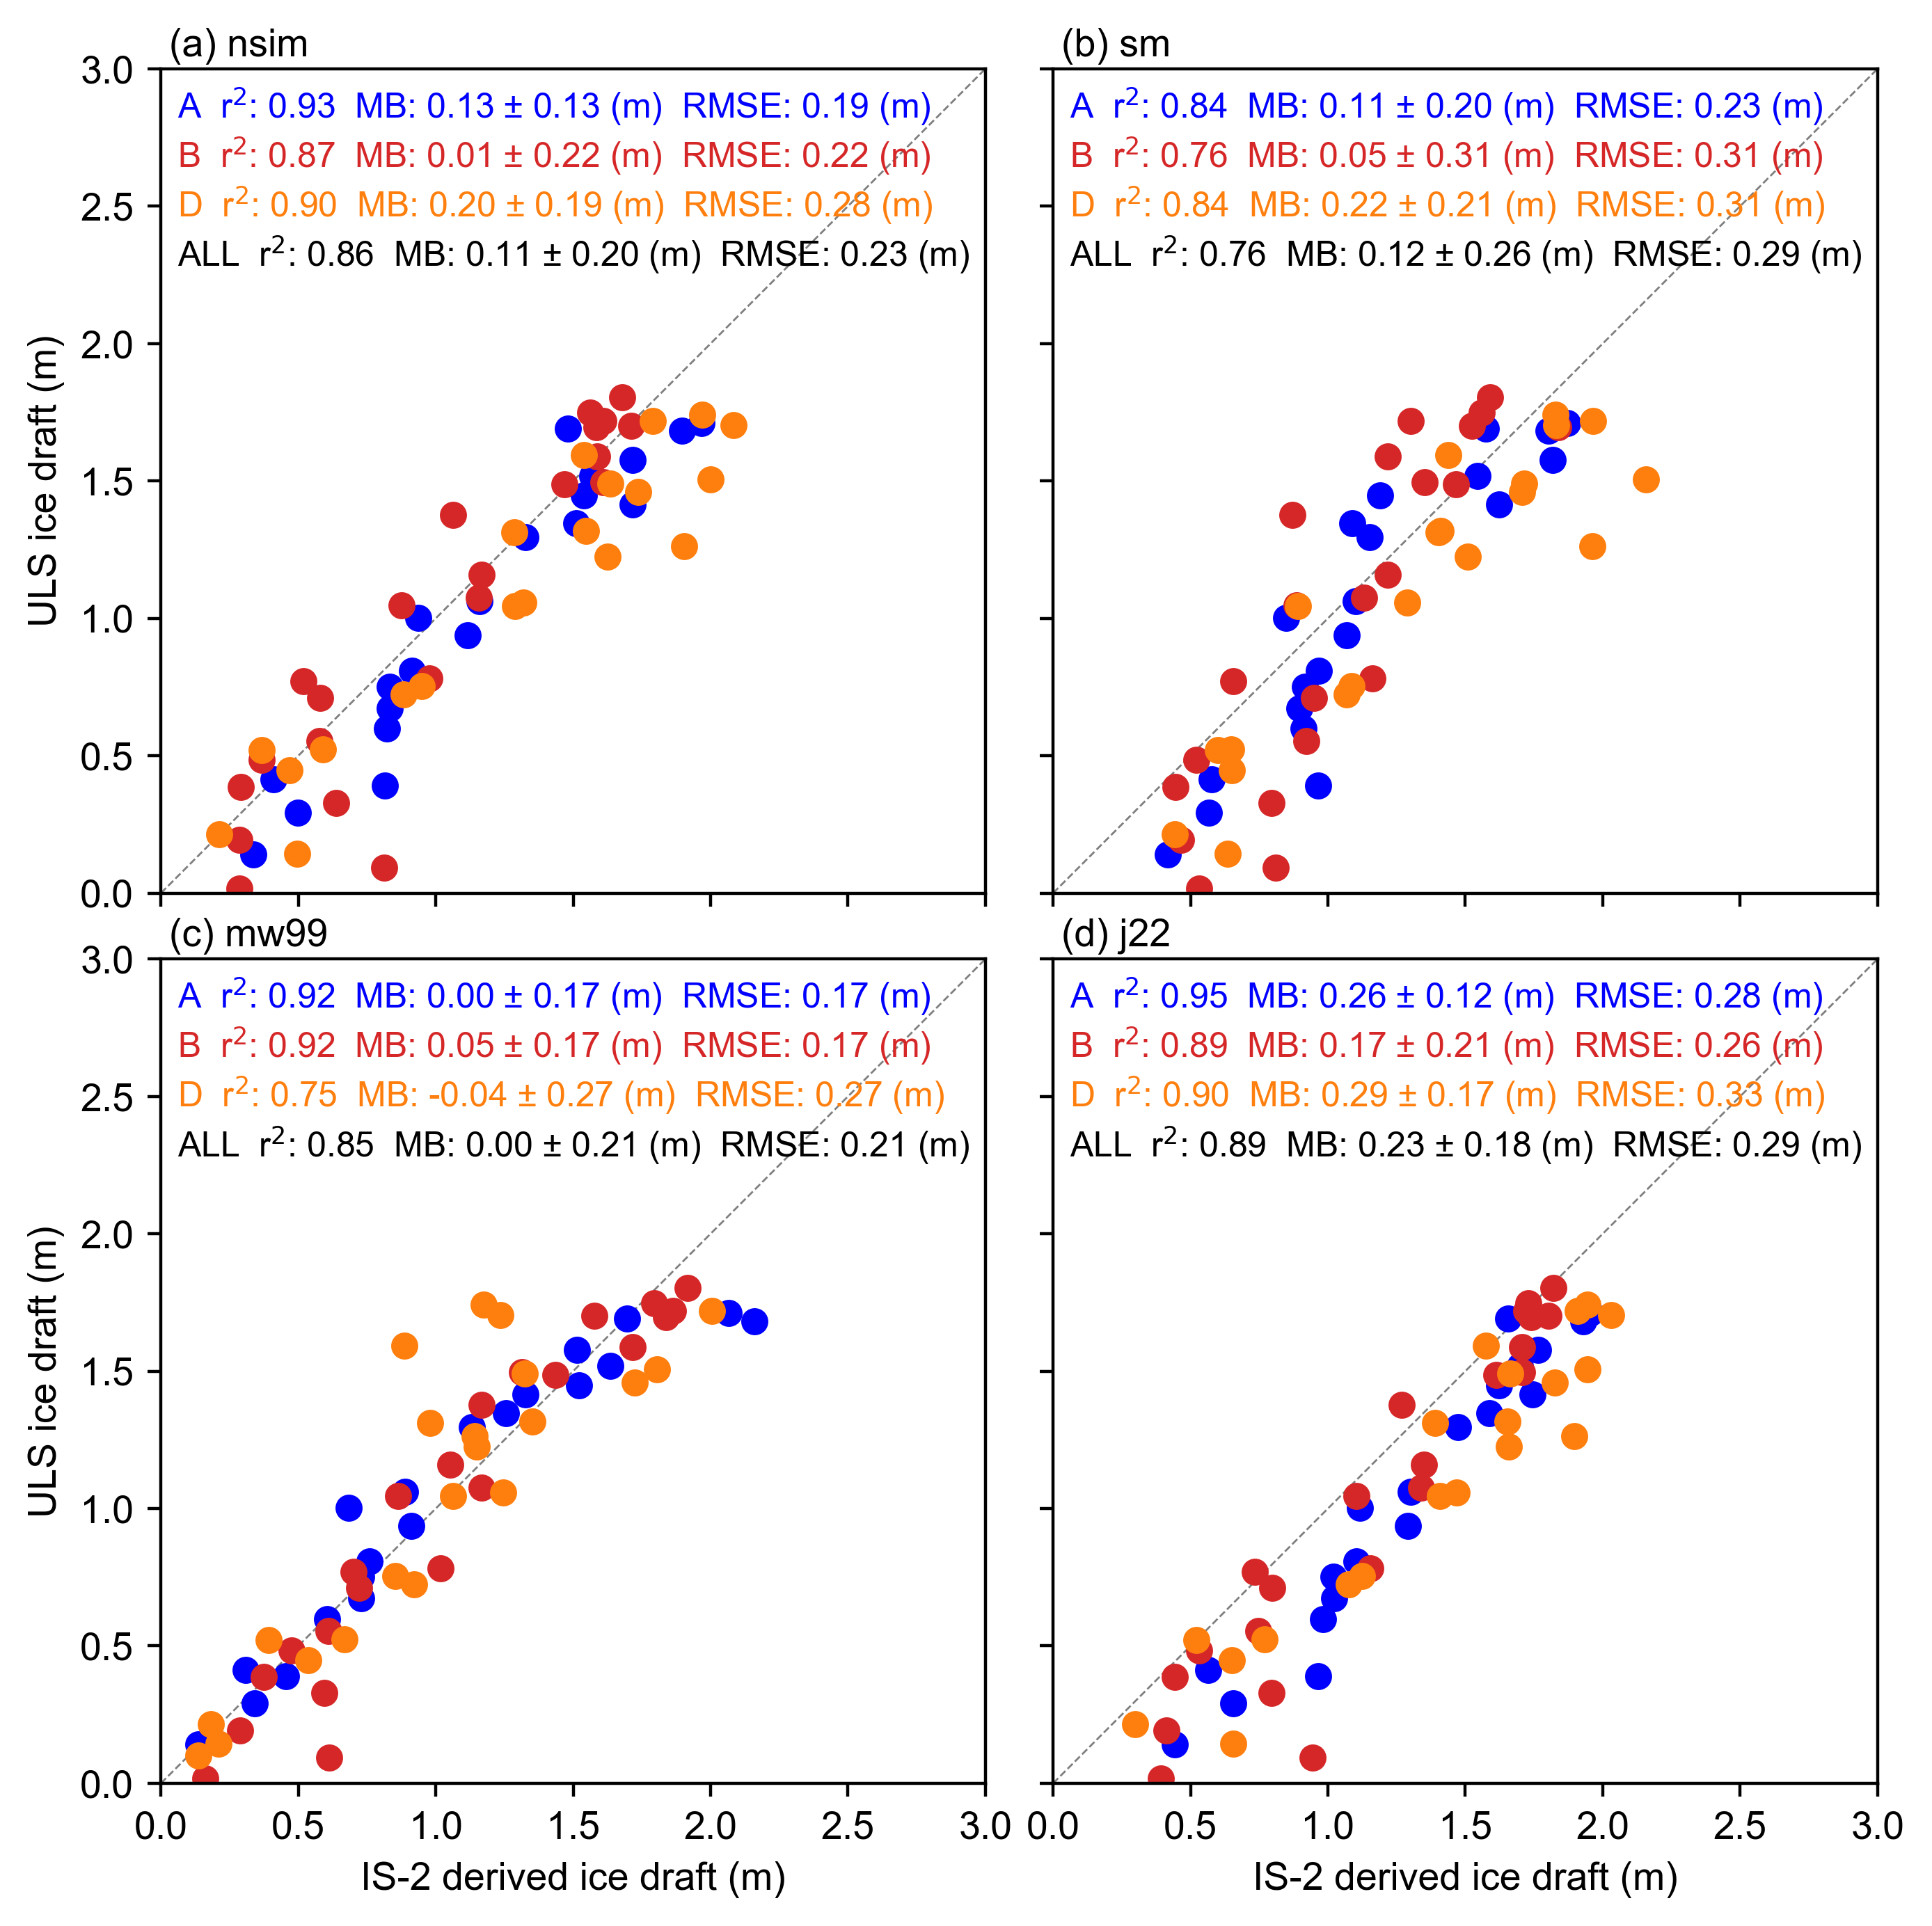

In [23]:
# ... existing code ...

# Validation plot with subplots for each option
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})
fig, axes = plt.subplots(2, 2, figsize=(8, 8), gridspec_kw={'hspace': 0.08, 'wspace': 0.07})  # Adjust hspace and wspace for less whitespace
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
panel_labels = ['(a)', '(b)', '(c)', '(d)']  # Panel labels

for i, option in enumerate(options.keys()):
    ax = axes[i]
    ax.scatter(monthly_IS2_at_ULS_a_options[option], uls_mean_monthly_draft_a_IS2_period, color='b', label='A')
    ax.scatter(monthly_IS2_at_ULS_b_options[option], uls_mean_monthly_draft_b_IS2_period, color='tab:red', label='B')
    ax.scatter(monthly_IS2_at_ULS_d_options[option], uls_mean_monthly_draft_d_IS2_period, color='tab:orange', label='D')

    # Retrieve validation results for the current option
    r_str_a = validation_results[option]['r_str_a']
    mb_str_a = validation_results[option]['mb_str_a']
    sd_str_a = validation_results[option]['sd_str_a']
    r_str_b = validation_results[option]['r_str_b']
    mb_str_b = validation_results[option]['mb_str_b']
    sd_str_b = validation_results[option]['sd_str_b']
    r_str_d = validation_results[option]['r_str_d']
    mb_str_d = validation_results[option]['mb_str_d']
    sd_str_d = validation_results[option]['sd_str_d']
    r_str_all = validation_results[option]['r_str_all']
    mb_str_all = validation_results[option]['mb_str_all']
    sd_str_all = validation_results[option]['sd_str_all']

    # Calculate RMSE for each ULS
    rmse_a = np.sqrt(np.nanmean((np.array(monthly_IS2_at_ULS_a_options[option]) - np.array(uls_mean_monthly_draft_a_IS2_period))**2))
    rmse_b = np.sqrt(np.nanmean((np.array(monthly_IS2_at_ULS_b_options[option]) - np.array(uls_mean_monthly_draft_b_IS2_period))**2))
    rmse_d = np.sqrt(np.nanmean((np.array(monthly_IS2_at_ULS_d_options[option]) - np.array(uls_mean_monthly_draft_d_IS2_period))**2))
    rmse_all = np.sqrt(np.nanmean((np.array(monthly_IS2_at_ULS_all_options[option]) - np.array(uls_mean_monthly_draft_IS2_period))**2))

    # Annotate the plot with RMSE, mean bias, and standard deviation
    ax.annotate(f"A  r$^2$: {r_str_a}  MB: {mb_str_a} ± {sd_str_a} (m)  RMSE: {rmse_a:.02f} (m)", color='b', xy=(0.02, 0.98), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    ax.annotate(f"B  r$^2$: {r_str_b}  MB: {mb_str_b} ± {sd_str_b} (m)  RMSE: {rmse_b:.02f} (m)", color='tab:red', xy=(0.02, 0.92), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    ax.annotate(f"D  r$^2$: {r_str_d}  MB: {mb_str_d} ± {sd_str_d} (m)  RMSE: {rmse_d:.02f} (m)", color='tab:orange', xy=(0.02, 0.86), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    ax.annotate(f"ALL  r$^2$: {r_str_all}  MB: {mb_str_all} ± {sd_str_all} (m)  RMSE: {rmse_all:.02f} (m)", color='k', xy=(0.02, 0.80), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)

    # Combine panel label with option label
    ax.annotate(f"{panel_labels[i]} "+option, xy=(0.01, 1.05), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top')

    # Set x and y labels only for the leftmost and bottom plots
    if i % 2 == 0:
        ax.set_ylabel('ULS ice draft (m)')
    else:
        ax.set_yticklabels('')
    if i >= 2:
        ax.set_xlabel('IS-2 derived ice draft (m)')
    else:
        ax.set_xlabel('')
        ax.set_xticklabels('')

    ax.set_xlim([0, 3])
    ax.set_ylim([0, 3])
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    #ax.legend()

plt.tight_layout()
plt.savefig('./figs/BGEP_scatter_res'+str(comp_res)+'_nn_'+start_date+end_date+'_subplots_4.pdf', dpi=200)
plt.show()

# ... existing code ...